Generates the plots and tables for the paper: "The Lisbon benchmark: a new real-world multi-domain bivariate causal discovery dataset"

In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors

from bicausal.helpers.utils import save_imgs, tuebingen_statistics
from bicausal.benchmarks.Lisbon.lisbon_analysers import obtain_source_specs, field_stats_excel, points_sources_stats
from bicausal.metrics.evaluators import evaluate_lisbon, construct_table, evaluate_tuebingen
from bicausal.metrics.drawers import plot_dataset_curves

all_methods=['ANM',"bQCD","CAM","CDCI","CDS","CGNN","FOM","HECI","IGCI","LCube","LOCI","NNCL","RECI","ROCHE","Slope","Sloppy"]

In [2]:
#Table 1: Summary statistics of the Lisbon benchmark by field

table_title="Lisbon paper - Table 1 - Summary statistics of the Lisbon benchmark by field"
field_stats_excel(table_title=table_title)

Field statistics (including 'all' summary) saved to: benchmarks/Lisbon\field_stats.xlsx


,Field,N_sources,N_examples,N_points_mean,N_x,N_y,Weight
0,agriculture_environment,9,37.555556,30956.666667,1.555556,1.222222,38.618758
1,biology_health,11,14.727273,633.909091,2.727273,1.545455,81.974560
2,economy,17,27.176471,23951.117647,2.294118,1.294118,101.132699
3,human_predictions,11,58.909091,16351.181818,3.545455,1.545455,103.838265
4,science_engineering,10,19.900000,13681.400000,4.400000,1.900000,110.802503
5,all,58,31.189655,17403.948276,2.862069,1.482759,436.366784


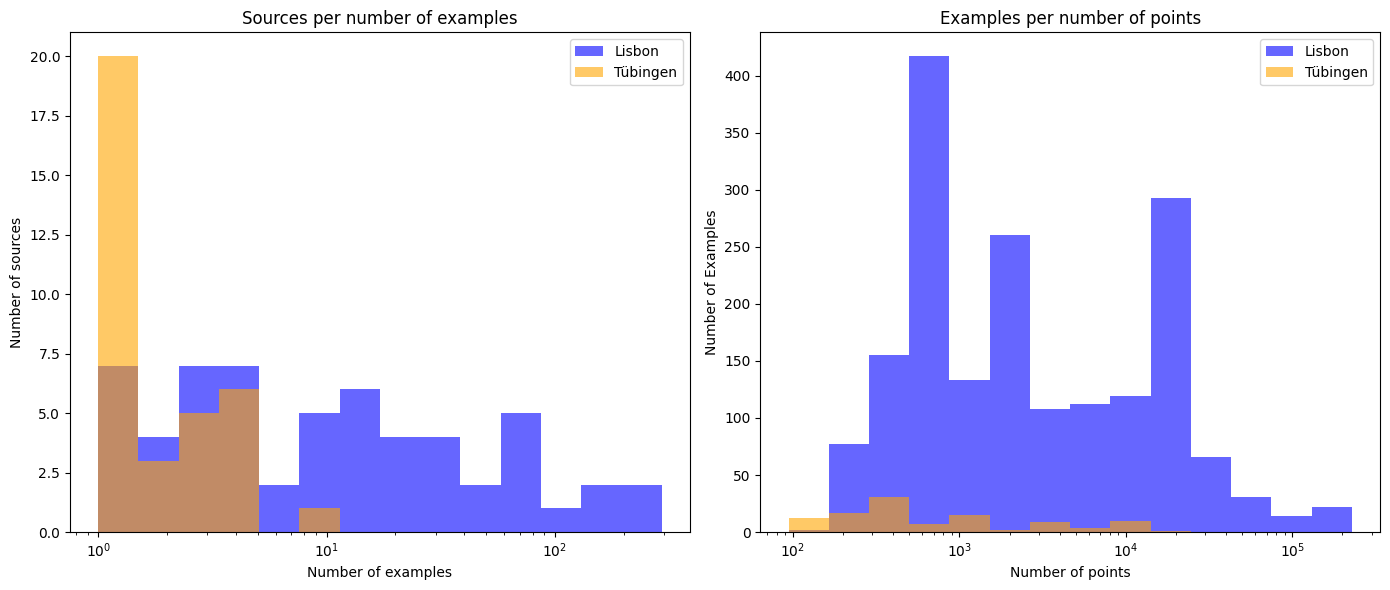

In [4]:
#Figure 1: Histograms of sources per number of examples and examples per number of points

lisbon_src, lisbon_points = points_sources_stats()
tuebingen_points, tuebingen_src = tuebingen_statistics()

plt.figure(figsize=(14, 6))

# -----------------------------------------
# Histogram 1: Examples per number of points
# -----------------------------------------
plt.subplot(1, 2, 2)

bins_points = np.logspace(
    np.log10(min(lisbon_points + tuebingen_points)),
    np.log10(max(lisbon_points + tuebingen_points)),
    15
)

plt.hist(lisbon_points, bins=bins_points, alpha=0.6, color="blue",label="Lisbon")
plt.hist(tuebingen_points, bins=bins_points, alpha=0.6, color="orange",label="Tübingen")

plt.xscale("log")
plt.xlabel("Number of points")
plt.ylabel("Number of Examples")
plt.title("Examples per number of points")
plt.legend()

# -----------------------------------------
# Histogram 2: Sources per number of examples
# -----------------------------------------
plt.subplot(1, 2, 1)

bins_examples = np.logspace(
    np.log10(min(lisbon_src + tuebingen_src)),
    np.log10(max(lisbon_src + tuebingen_src)),
    15
)

plt.hist(lisbon_src, bins=bins_examples, alpha=0.6, color="blue",label="Lisbon")
plt.hist(tuebingen_src, bins=bins_examples, alpha=0.6, color="orange",label="Tübingen")

plt.xscale("log")
plt.xlabel("Number of examples")
plt.ylabel("Number of sources")
plt.title("Sources per number of examples")
plt.legend()

plt.tight_layout()

save_imgs("Lisbon paper - Figure 1 - Histograms of sources per number of examples and examples per number of points", "plots")
plt.show()

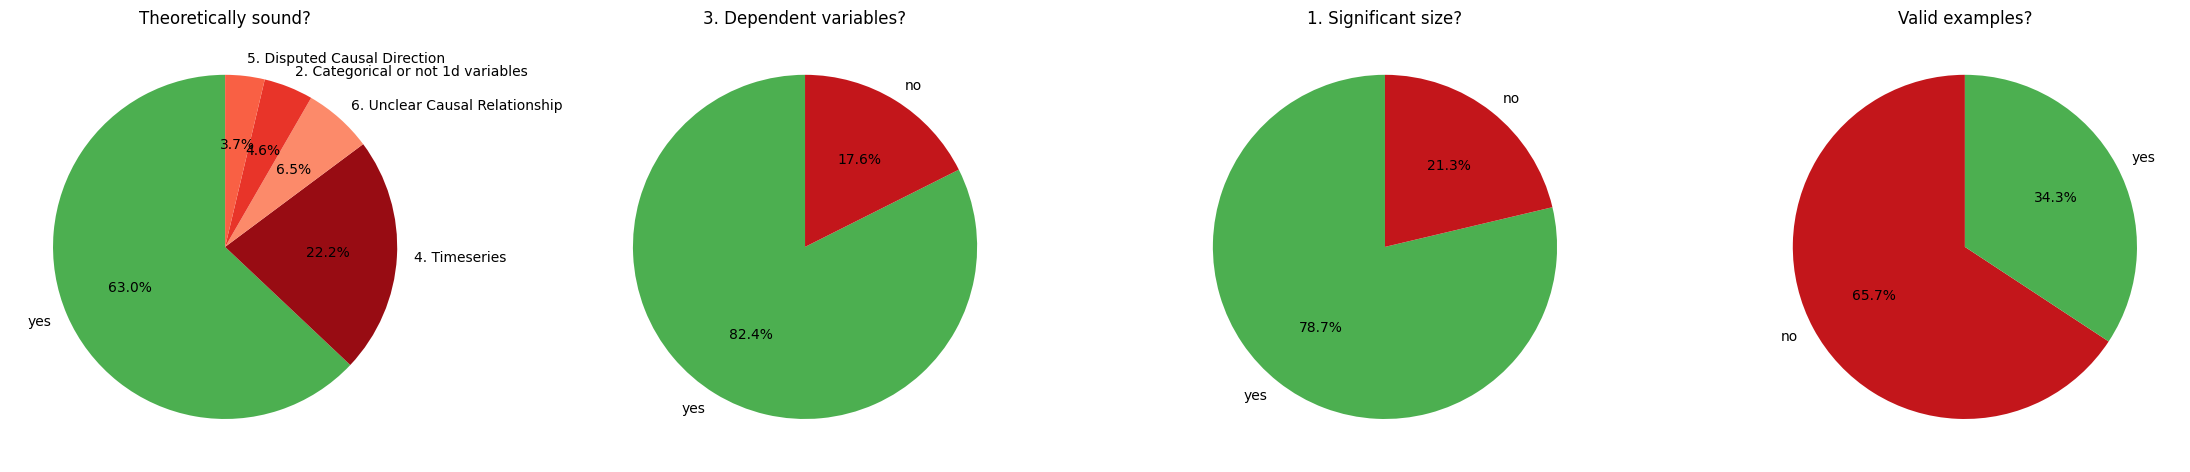

In [5]:
#Figure 2: Validity of Tuebingen examples

excel_path="benchmarks/Tuebingen/TuebingenAnalysis.xlsx"
df = pd.read_excel(excel_path)

# Validity columns to plot
columns = [
    "Theoretically sound?",
    "Dependent variables?",
    "Significant size?",
    "Valid examples?"
]

# Define base colors
yes_color = "#4CAF50"
    
# Mapping for the first chart's categories
first_chart_mapping = {
    "2": "2. Categorical or not 1d variables",
    "5": "5. Disputed Causal Direction",
    "6": "6. Unclear Causal Relationship",
    "timeseries": "4. Timeseries"
}

# Collect all unique answers for generating red shades
all_answers = set()
for col in columns:
    all_answers.update(df[col].unique())

# Rename timeseries in first chart to match mapping
all_answers = set([first_chart_mapping.get(str(a), str(a)) for a in all_answers])

# Determine non-yes answers for red shades
red_answers = [ans for ans in all_answers if str(ans).lower() != "yes"]
n_red = len(red_answers)
# Generate red shades
red_shades = [mcolors.to_hex(c) for c in plt.cm.Reds(np.linspace(0.4, 0.9, n_red))]
red_map = dict(zip(red_answers, red_shades))

# Complete color map
color_map = {"yes": yes_color}
color_map.update(red_map)
    
# Plotting
fig, axes = plt.subplots(1, 4, figsize=(22, 6))

for i, (ax, col) in enumerate(zip(axes, columns)):
    counts = df[col].value_counts()
    labels = counts.index
    sizes = counts.values
    
    # Rename labels for first chart
    if i == 0:
        labels = [first_chart_mapping.get(str(label), str(label)) for label in labels]
    
    # Map colors
    colors = [color_map.get(str(label), "#DDDDDD") for label in labels]  # fallback gray
    
    ax.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
    
    # Add numbering for 2nd ("3.") and 3rd ("1.") charts
    if i == 1:
        title = f"3. {col}"
    elif i == 2:
        title = f"1. {col}"
    else:
        title = col
    ax.set_title(title)

plt.tight_layout()
save_imgs("Lisbon paper - Figure 2 - Validity of Tuebingen examples", "plots")
plt.show()

In [6]:
#Table 2: Results of all methods in the Lisbon benchmark
evaluate_lisbon(methods=all_methods,metrics=["LxCIM","accuracy","AUROC","AUDRC"])
construct_table(methods=all_methods, datasets=["Lisbon"], metrics=["LxCIM","accuracy","AUROC","AUDRC"], include_variations=True,table_title="Lisbon paper - Table 2 - Lisbon results")

✅ Evaluation complete. Results written to results/results.csv
✅ Evaluation complete. Results written to results/results.csv
✅ Evaluation complete. Results written to results/results.csv
✅ Evaluation complete. Results written to results/results.csv
✅ Evaluation complete. Results written to results/results.csv
✅ Evaluation complete. Results written to results/results.csv

RESULT TABLE
| Method   | Parameters                                       | Dataset   |   LxCIM (%) |   Accuracy (%) |   AUROC (%) |   AUDRC (%) |
|----------|--------------------------------------------------|-----------|-------------|----------------|-------------|-------------|
| ANM      |                                                  | Lisbon    |        56.9 |           57.6 |        57.2 |        58.3 |
| bQCD     |                                                  | Lisbon    |        60.1 |           59.4 |        60.2 |        59.7 |
| CAM      |                                                  | Lisbon    

,Method,Parameters,Dataset,LxCIM (%),Accuracy (%),AUROC (%),AUDRC (%)
0,ANM,,Lisbon,56.9,57.6,57.2,58.3
15,bQCD,,Lisbon,60.1,59.4,60.2,59.7
1,CAM,,Lisbon,47.1,49.7,47.1,44.5
2,CDCI,,Lisbon,62.4,57.5,62.4,65.3
3,CDS,,Lisbon,47.7,50.3,47.8,43.7
4,CGNN,"{""nruns"": 3,""test_epochs"": 2,""train_epochs"": 10}",Lisbon,50.7,51.4,50.5,52.1
5,FOM,,Lisbon,38.9,42.4,39.1,37.2
6,HECI,,Lisbon,56.3,58.3,56.4,54.2
7,IGCI,,Lisbon,66.0,63.2,65.8,64.1
8,LCube,,Lisbon,46.4,40.0,46.2,51.5


(<Figure size 2100x600 with 3 Axes>,
 array([<Axes: title={'center': 'Lisbon - LxCIM'}, xlabel='Decision Rate', ylabel='Cumulative Accuracy'>,
        <Axes: title={'center': 'Lisbon - AUROC'}, xlabel='False Positive Rate (FPR)', ylabel='True Positive Rate (TPR)'>,
        <Axes: title={'center': 'Lisbon - AUDRC'}, xlabel='Decision Rate', ylabel='Accuracy'>],
       dtype=object))

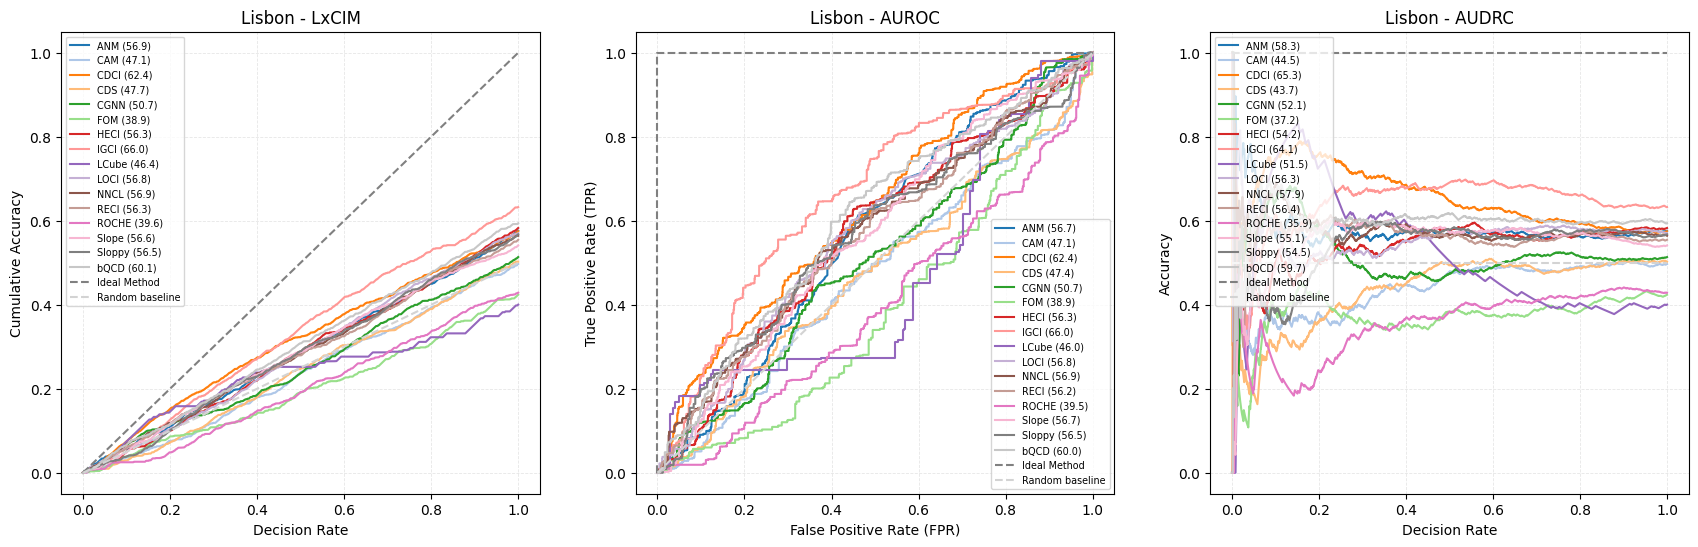

In [9]:
plot_dataset_curves("Lisbon", methods=all_methods, metrics=["LxCIM","AUROC","AUDRC"],include_variations=True, show_params=False, figure_name="Lisbon paper - Figure 3 - Lisbon curves")

✅ Evaluation complete. Results written to results/results.csv
✅ Evaluation complete. Results written to results/results.csv
✅ Evaluation complete. Results written to results/results.csv
✅ Evaluation complete. Results written to results/results.csv
✅ Evaluation complete. Results written to results/results.csv
✅ Evaluation complete. Results written to results/results.csv

RESULT TABLE
| Method   | Parameters                                       | Dataset                          |   LxCIM (%) |   Accuracy (%) |   AUROC (%) |   AUDRC (%) |
|----------|--------------------------------------------------|----------------------------------|-------------|----------------|-------------|-------------|
| ANM      |                                                  | Lisbon                           |        56.9 |           57.6 |        57   |        58.3 |
| ANM      |                                                  | Lisbon - agriculture_environment |        53.1 |           54.1 |        53.

(<Figure size 2100x600 with 3 Axes>,
 array([<Axes: title={'center': 'Lisbon - science_engineering - LxCIM'}, xlabel='Decision Rate', ylabel='Cumulative Accuracy'>,
        <Axes: title={'center': 'Lisbon - science_engineering - AUROC'}, xlabel='False Positive Rate (FPR)', ylabel='True Positive Rate (TPR)'>,
        <Axes: title={'center': 'Lisbon - science_engineering - AUDRC'}, xlabel='Decision Rate', ylabel='Accuracy'>],
       dtype=object))

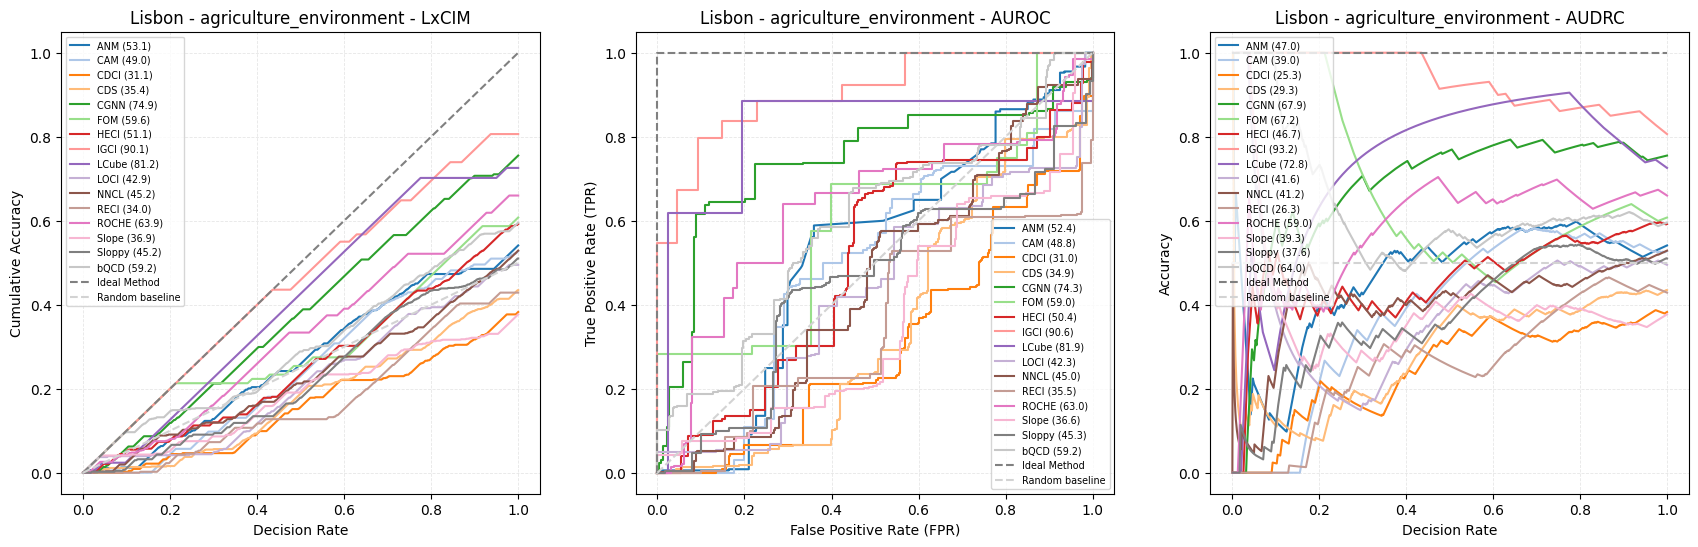

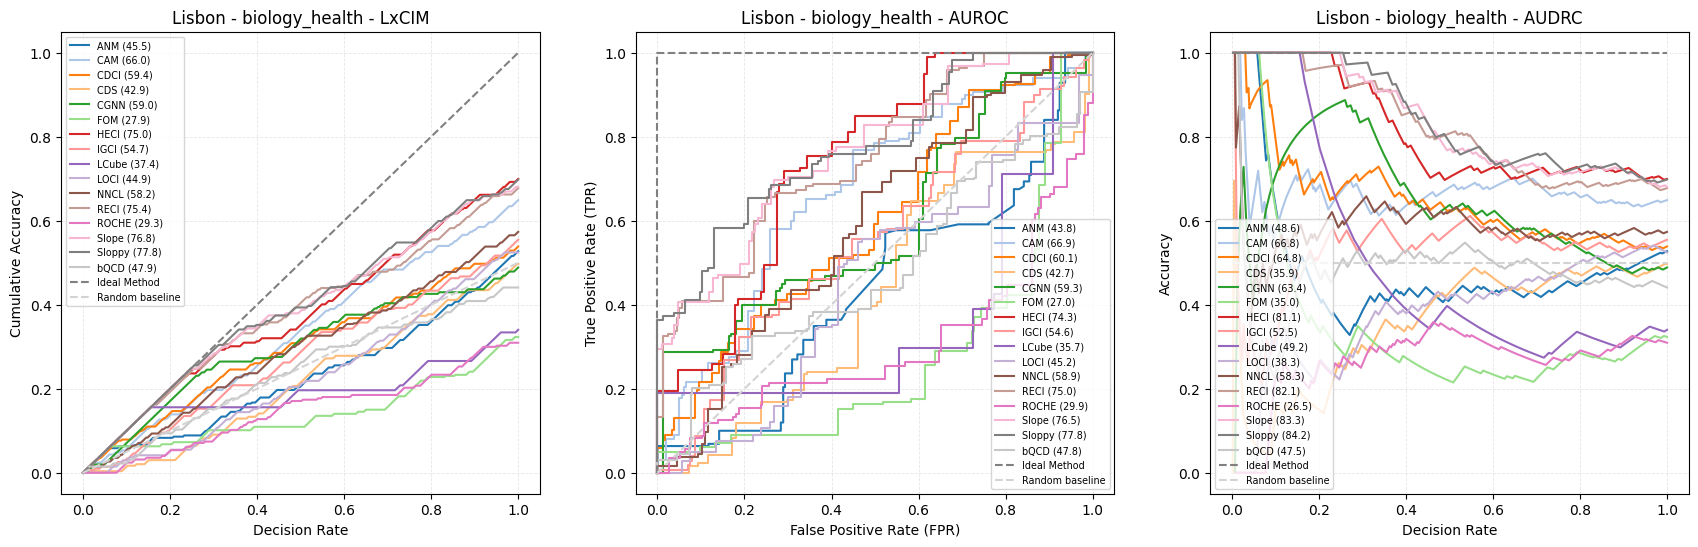

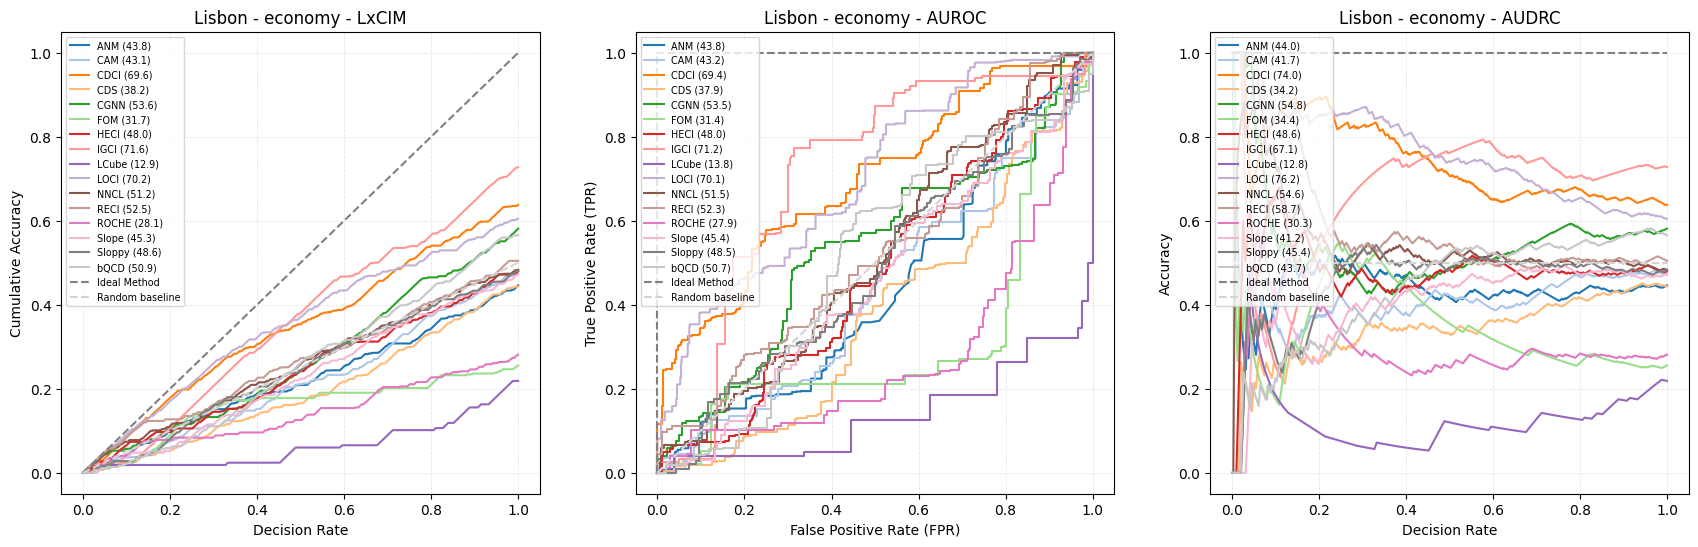

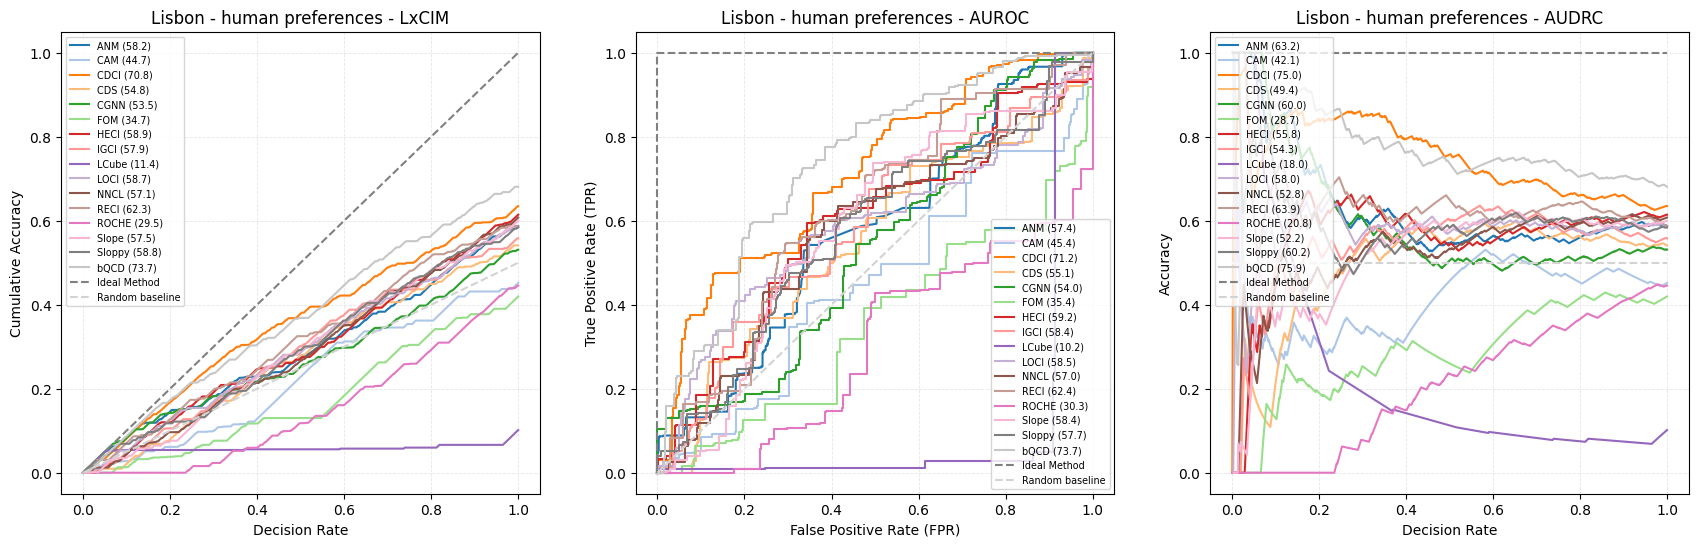

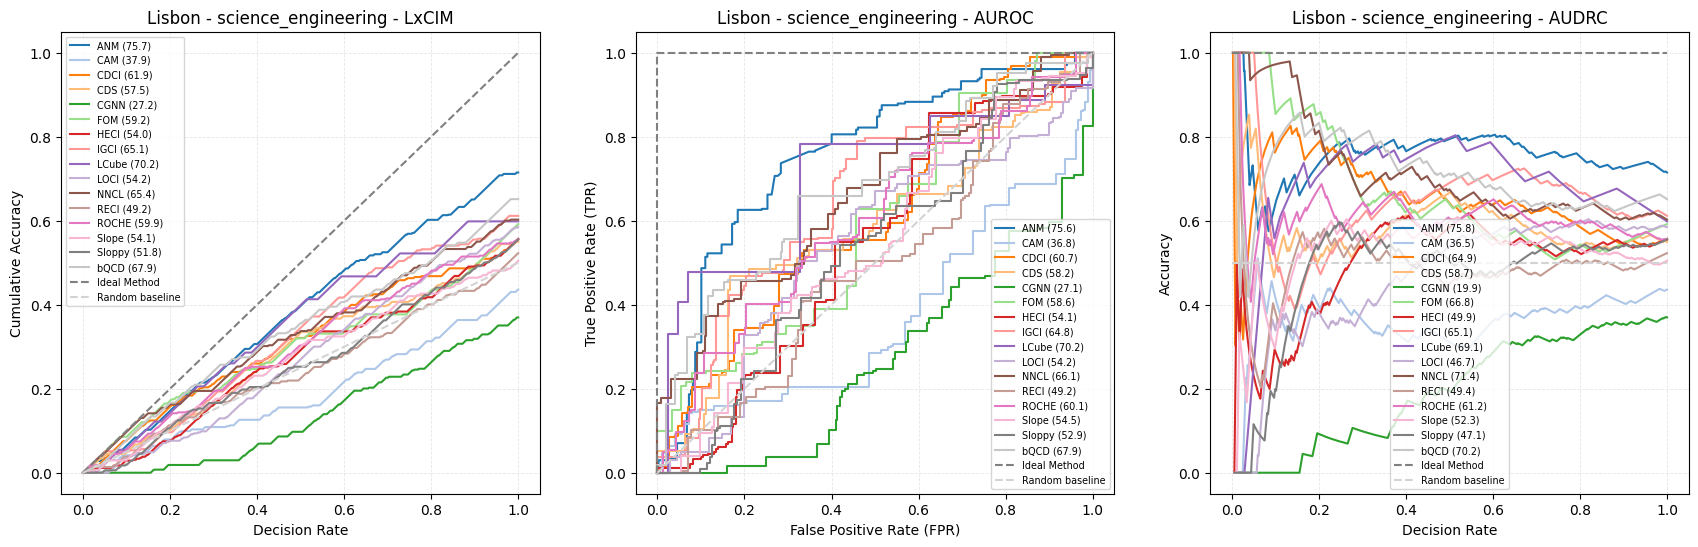

In [6]:
#Appendix: Additional Results on the Lisbon Benchmark
evaluate_lisbon(methods=all_methods,metrics=["LxCIM","accuracy","AUROC","AUDRC"])
construct_table(methods=all_methods, datasets=["Lisbon","Lisbon - agriculture_environment","Lisbon - biology_health","Lisbon - economy","Lisbon - human_predictions","Lisbon - science_engineering"], metrics=["LxCIM","accuracy","AUROC","AUDRC"], include_variations=True,table_title="Lisbon paper - Appendix A - Lisbon results appendix")
plot_dataset_curves("Lisbon - agriculture_environment", methods=all_methods, metrics=["LxCIM","AUROC","AUDRC"],include_variations=True, show_params=False, figure_name="Lisbon paper - Appendix Figure 4 - Agriculture_environment curves appendix")
plot_dataset_curves("Lisbon - biology_health", methods=all_methods, metrics=["LxCIM","AUROC","AUDRC"],include_variations=True, show_params=False, figure_name="Lisbon paper - Appendix Figure 5 - Biology_health curves appendix")
plot_dataset_curves("Lisbon - economy", methods=all_methods, metrics=["LxCIM","AUROC","AUDRC"],include_variations=True, show_params=False, figure_name="Lisbon paper - Appendix Figure 6 - Economy curves appendix")
plot_dataset_curves("Lisbon - human_predictions", methods=all_methods, metrics=["LxCIM","AUROC","AUDRC"],include_variations=True, show_params=False, figure_name="Lisbon paper - Appendix Figure 7 - Human_predictions curves appendix")
plot_dataset_curves("Lisbon - science_engineering", methods=all_methods, metrics=["LxCIM","AUROC","AUDRC"],include_variations=True, show_params=False, figure_name="Lisbon paper - Appendix Figure 8 - Science_engineering curves appendix")

✅ Evaluation complete. Results written to results/results.csv

RESULT TABLE
| Method   | Parameters                                       | Dataset   |   LxCIM (%) |   Accuracy (%) |   AUROC (%) |   AUDRC (%) |
|----------|--------------------------------------------------|-----------|-------------|----------------|-------------|-------------|
| ANM      |                                                  | Tübingen  |        61.7 |           60.4 |        60   |        62.9 |
| bQCD     |                                                  | Tübingen  |        71.1 |           69.6 |        71.6 |        70.1 |
| CAM      |                                                  | Tübingen  |        45.7 |           52.3 |        44.5 |        43.1 |
| CDCI     |                                                  | Tübingen  |        59.4 |           61.5 |        58.1 |        55   |
| CDS      |                                                  | Tübingen  |        60.2 |           60.5 |        

(<Figure size 2100x600 with 3 Axes>,
 array([<Axes: title={'center': 'Tübingen - LxCIM'}, xlabel='Decision Rate', ylabel='Cumulative Accuracy'>,
        <Axes: title={'center': 'Tübingen - AUROC'}, xlabel='False Positive Rate (FPR)', ylabel='True Positive Rate (TPR)'>,
        <Axes: title={'center': 'Tübingen - AUDRC'}, xlabel='Decision Rate', ylabel='Accuracy'>],
       dtype=object))

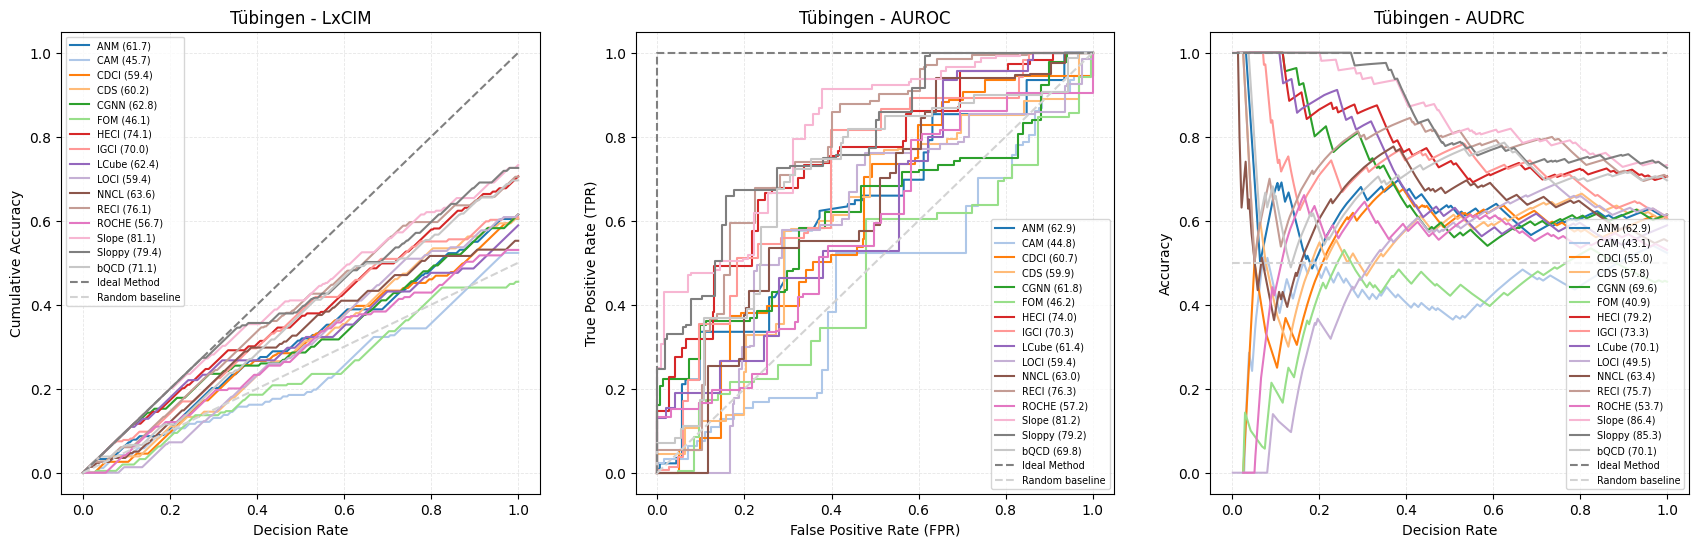

In [10]:
evaluate_tuebingen(methods=all_methods,metrics=["LxCIM","accuracy","AUROC","AUDRC"])
construct_table(methods=all_methods, datasets=["Tuebingen"], metrics=["LxCIM","accuracy","AUROC","AUDRC"], include_variations=True,table_title="Lisbon paper - Appendix B - Tuebingen results appendix")
plot_dataset_curves("Tuebingen", methods=all_methods, metrics=["LxCIM","AUROC","AUDRC"],include_variations=True, show_params=False, figure_name="Lisbon paper - Figure 4 - Tuebingen curves")